# TA Features + SHAP Selection Experiment

**Hypothesis**: Adding 6 TA/Qlib features to the 30-feature model hurts performance
not because the features are uninformative, but because the expanded 36-feature pool
introduces too much noise for a small dataset (~1,285 rows, shallow trees).

**Approach**: Fold-local SHAP selection (leakage-free).
For each fold:
1. Train on all 36 features using the training window
2. Compute SHAP importance on **training data only** (no leakage from test)
3. Select the top-N features by mean |SHAP| across classes
4. Retrain on those N features using the same training window
5. Evaluate on the test window

**Tested**: N = 20, 25, 30 features selected from the 36-feature pool

**Baseline** (shown for reference): locked 30-feature model (`lgbm_3class_xfn5d_30f`)

> Run cells top-to-bottom. If any N beats the baseline on both ASA and Dir AUC,
> set `SAVE = True` in the final cell.

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
from datetime import date
from itertools import product as iterproduct

import numpy as np
import pandas as pd
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score

warnings.filterwarnings('ignore')

NOTEBOOK_DIR  = Path('').resolve()
ROOT          = NOTEBOOK_DIR.parents[2]
EXP_PARENT    = ROOT / 'step3_predictive_model/model_experiments'
FINAL_ART_DIR = ROOT / 'step3_predictive_model/final_model/artifacts'
EXP_ART_DIR   = NOTEBOOK_DIR / 'artifacts'
EXP_ART_DIR.mkdir(exist_ok=True)

for p in [str(ROOT), str(EXP_PARENT)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print(f'ROOT            : {ROOT}')
print(f'Experiment arts : {EXP_ART_DIR}')

ROOT            : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis
Experiment arts : /Users/yanyan/Desktop/Projects/AI_driven_company_and_stock_analysis/step3_predictive_model/model_experiments/final_model_experiment/artifacts


## 1. Load Baseline Config & Dataset

In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class
from src.models.walk_forward_config import E10_FOLDS, STRIDE_EVAL

# Load locked config (features, target, threshold, params) — never written to
locked_pkls = sorted(FINAL_ART_DIR.glob('lgbm_3class_xfn5d_30f_tuned-*.pkl'))
assert locked_pkls
with open(locked_pkls[-1], 'rb') as f:
    locked = pickle.load(f)

BASE_FEATURES = locked['features']
TARGET        = locked['target']
THRESHOLD     = locked['threshold']
label_map     = locked['label_map']
inv_map       = locked['inverse_label_map']
LOCKED_PARAMS = locked['best_params']

df = load_dataset()
print(f'Dataset      : {len(df)} rows  |  {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Base features: {len(BASE_FEATURES)}')
print(f'Params       : {LOCKED_PARAMS}')

Dataset      : 1285 rows  |  2021-02-25 → 2026-04-09
Base features: 30
Params       : {'learning_rate': 0.05, 'feature_fraction': 0.8, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'num_leaves': 8, 'min_child_samples': 40, 'n_estimators': 120}


## 2. Full 36-Feature Pool

In [3]:
TA_ADDITIONS = ['td_rsi_14', 'td_bb_position', 'td_rsv_14d',
                'td_beta_20d', 'td_resi_20d', 'td_wvma_5d']

POOL_36 = BASE_FEATURES + TA_ADDITIONS   # all 36 features

missing = [f for f in POOL_36 if f not in df.columns]
assert not missing, f'Missing: {missing}'

print(f'Pool size : {len(POOL_36)} features  ({len(BASE_FEATURES)} base + {len(TA_ADDITIONS)} TA)')
print(f'\nTA additions:')
for f in TA_ADDITIONS:
    print(f'  {f}')

STRIDE  = STRIDE_EVAL
OFFSETS = list(range(STRIDE))

Pool size : 36 features  (30 base + 6 TA)

TA additions:
  td_rsi_14
  td_bb_position
  td_rsv_14d
  td_beta_20d
  td_resi_20d
  td_wvma_5d


## 3. Helper Functions

In [4]:
def offset_metrics(preds, y_true_cls, y_true_cont, dates, proba=None):
    rows = []
    for off in OFFSETS:
        idx    = np.arange(off, len(dates), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        d_auc  = np.nan
        if proba is not None:
            pb = proba[idx]
            try:
                auc_long  = roc_auc_score((y_cls == 1).astype(int),  pb[:, 2])
                auc_short = roc_auc_score((y_cls == -1).astype(int), pb[:, 0])
                d_auc = (auc_long + auc_short) / 2
            except ValueError:
                pass
        rows.append({
            'mean_acc':   (p == y_cls).mean(),
            'macro_f1':   f1_score(y_cls, p, average='macro', zero_division=0, labels=[-1, 0, 1]),
            'active_cov': active.mean(),
            'active_asa': float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                          if active.sum() > 0 else np.nan,
            'dir_auc':    d_auc,
        })
    return pd.DataFrame(rows).mean()


def train_and_predict(tr, te, feature_list, params):
    """Train on tr, predict on te. Returns (clf, preds, y_cls, y_cont, proba)."""
    x_tr  = tr[feature_list].fillna(tr[feature_list].median())
    y_tr  = label_3class(tr[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([label_map[v] for v in y_tr], dtype=int)
    clf   = lgb.LGBMClassifier(
        objective='multiclass', num_class=3,
        random_state=42, verbose=-1, n_jobs=1, **params
    )
    clf.fit(x_tr, y_enc)
    x_te      = te[feature_list].fillna(tr[feature_list].median())
    y_te_cls  = label_3class(te[TARGET].values, threshold=THRESHOLD)
    y_te_cont = te[TARGET].values
    preds     = np.array([inv_map[p] for p in clf.predict(x_te)])
    proba     = clf.predict_proba(x_te)
    return clf, preds, y_te_cls, y_te_cont, proba


def shap_importance(clf, x_train):
    """Mean |SHAP| across all classes for a trained LGBMClassifier."""
    explainer = shap.TreeExplainer(clf)
    sv = explainer.shap_values(x_train)
    if isinstance(sv, list):
        return np.mean([np.abs(s).mean(axis=0) for s in sv], axis=0)
    sv = np.array(sv)
    return np.abs(sv).mean(axis=(0, 2)) if sv.ndim == 3 and sv.shape[-1] == 3            else np.abs(sv).mean(axis=(0, 1))


print('Helper functions defined.')

Helper functions defined.


## 4. Fold-Local SHAP Selection Walk-Forward

For each fold and each target size N ∈ {20, 25, 30}:
1. Train on all 36 features using the training window
2. Compute SHAP on **training data only** (leakage-free)
3. Rank features by mean |SHAP|, keep top N
4. Retrain on top-N features
5. Evaluate on test window

This also tracks **which TA features are selected per fold**, so we can see
whether the TA additions ever make it into the top-N.

In [5]:
TOP_N_VALUES = [20, 25, 30]

# Storage: results[N] = list of per-fold metric dicts
results      = {n: [] for n in TOP_N_VALUES}
# Track per-fold feature selections: selected_features[N][fold_id] = list of features
selected_features = {n: {} for n in TOP_N_VALUES}
# Track SHAP importances across folds for the 36-feature pool
shap_records = []   # list of pd.Series (one per fold)

print(f'Running fold-local SHAP selection on {len(POOL_36)}-feature pool')
print(f'Testing top-N: {TOP_N_VALUES}')
print(f'Folds: {len(E10_FOLDS)}')
print()

for fold_id, train_end, test_start, test_end in E10_FOLDS:
    tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    te_mask = ((df['date'] >= pd.Timestamp(test_start)) &
               (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
    tr, te = df[tr_mask], df[te_mask]

    # ── Step 1: train on full 36-feature pool ────────────────────────────────
    clf_full, _, _, _, _ = train_and_predict(tr, te, POOL_36, LOCKED_PARAMS)

    # ── Step 2: SHAP on training data only ───────────────────────────────────
    x_tr_full = tr[POOL_36].fillna(tr[POOL_36].median())
    imp       = shap_importance(clf_full, x_tr_full)
    imp_ser   = pd.Series(imp, index=POOL_36, name=fold_id)
    shap_records.append(imp_ser)

    # ── Steps 3-5: for each N, select top-N and evaluate ─────────────────────
    for n in TOP_N_VALUES:
        top_n_feats = imp_ser.nlargest(n).index.tolist()
        selected_features[n][fold_id] = top_n_feats

        _, preds, y_cls, y_cont, proba = train_and_predict(
            tr, te, top_n_feats, LOCKED_PARAMS
        )
        m = offset_metrics(preds, y_cls, y_cont, te['date'].values, proba=proba)
        results[n].append({'fold': fold_id, **m.to_dict()})

    # Progress
    r30 = pd.DataFrame([results[30][-1]])
    print(f'Fold {fold_id}  |  '
          + '  '.join(f'top-{n}: ASA={pd.DataFrame(results[n])["active_asa"].iloc[-1]:.3f}'
                      for n in TOP_N_VALUES))

print('\nDone.')

Running fold-local SHAP selection on 36-feature pool
Testing top-N: [20, 25, 30]
Folds: 7



Fold v1  |  top-20: ASA=0.606  top-25: ASA=0.635  top-30: ASA=0.659


Fold v2  |  top-20: ASA=0.542  top-25: ASA=0.546  top-30: ASA=0.535


Fold v3  |  top-20: ASA=0.598  top-25: ASA=0.600  top-30: ASA=0.629


Fold v4  |  top-20: ASA=0.611  top-25: ASA=0.640  top-30: ASA=0.582


Fold v5  |  top-20: ASA=0.377  top-25: ASA=0.297  top-30: ASA=0.378


Fold v6  |  top-20: ASA=0.657  top-25: ASA=0.634  top-30: ASA=0.674


Fold v7  |  top-20: ASA=0.604  top-25: ASA=0.588  top-30: ASA=0.558

Done.


## 5. Results vs Baseline

In [6]:
# ── Compute baseline (run once with the locked 30 features) ──────────────────
print('Computing baseline …', end=' ')
baseline_rows = []
for fold_id, train_end, test_start, test_end in E10_FOLDS:
    tr_mask = (df['date'] <= pd.Timestamp(train_end)) & df[TARGET].notna()
    te_mask = ((df['date'] >= pd.Timestamp(test_start)) &
               (df['date'] <= pd.Timestamp(test_end)) & df[TARGET].notna())
    tr, te = df[tr_mask], df[te_mask]
    _, preds, y_cls, y_cont, proba = train_and_predict(
        tr, te, BASE_FEATURES, LOCKED_PARAMS
    )
    m = offset_metrics(preds, y_cls, y_cont, te['date'].values, proba=proba)
    baseline_rows.append({'fold': fold_id, **m.to_dict()})
baseline_df = pd.DataFrame(baseline_rows).set_index('fold')
bl = baseline_df.mean()
print(f'ASA={bl.active_asa:.3f}  DirAUC={bl.dir_auc:.3f}  F1={bl.macro_f1:.3f}')

# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = [{'Setup': 'Baseline (30f, no SHAP sel)',
                 'Features': 30,
                 'Active ASA': round(float(bl.active_asa), 3),
                 'Dir AUC':   round(float(bl.dir_auc),    3),
                 'Macro F1':  round(float(bl.macro_f1),   3),
                 'Coverage':  round(float(bl.active_cov), 3)}]

result_dfs = {}
for n in TOP_N_VALUES:
    rdf = pd.DataFrame(results[n]).set_index('fold')
    result_dfs[n] = rdf
    m = rdf.mean()
    summary_rows.append({
        'Setup':       f'Top-{n} SHAP (from 36f pool)',
        'Features':    n,
        'Active ASA':  round(float(m.active_asa), 3),
        'Dir AUC':     round(float(m.dir_auc),    3),
        'Macro F1':    round(float(m.macro_f1),   3),
        'Coverage':    round(float(m.active_cov), 3),
    })

summary_df = pd.DataFrame(summary_rows).set_index('Setup')
print('\n=== 7-Fold Average — SHAP Selection vs Baseline ===')
display(summary_df)

print('\n=== Delta vs Baseline ===')
for name, row in summary_df.iterrows():
    if name == 'Baseline (30f, no SHAP sel)':
        continue
    d_asa = row['Active ASA'] - bl.active_asa
    d_auc = row['Dir AUC']    - bl.dir_auc
    d_f1  = row['Macro F1']   - bl.macro_f1
    beats = '✓ BEATS BASELINE' if d_asa > 0 and d_auc > 0 else '✗'
    print(f'  {name:<35}  ΔASA={d_asa:+.3f}  ΔDirAUC={d_auc:+.3f}  ΔF1={d_f1:+.3f}   {beats}')

Computing baseline … 

ASA=0.600  DirAUC=0.566  F1=0.359

=== 7-Fold Average — SHAP Selection vs Baseline ===


,Features,Active ASA,Dir AUC,Macro F1,Coverage
Setup,,,,,
"Baseline (30f, no SHAP sel)",30,0.600,0.566,0.359,0.943
Top-20 SHAP (from 36f pool),20,0.571,0.566,0.346,0.939
Top-25 SHAP (from 36f pool),25,0.563,0.547,0.344,0.943
Top-30 SHAP (from 36f pool),30,0.573,0.552,0.356,0.932



=== Delta vs Baseline ===
  Top-20 SHAP (from 36f pool)          ΔASA=-0.029  ΔDirAUC=-0.000  ΔF1=-0.013   ✗
  Top-25 SHAP (from 36f pool)          ΔASA=-0.037  ΔDirAUC=-0.019  ΔF1=-0.015   ✗
  Top-30 SHAP (from 36f pool)          ΔASA=-0.027  ΔDirAUC=-0.014  ΔF1=-0.003   ✗


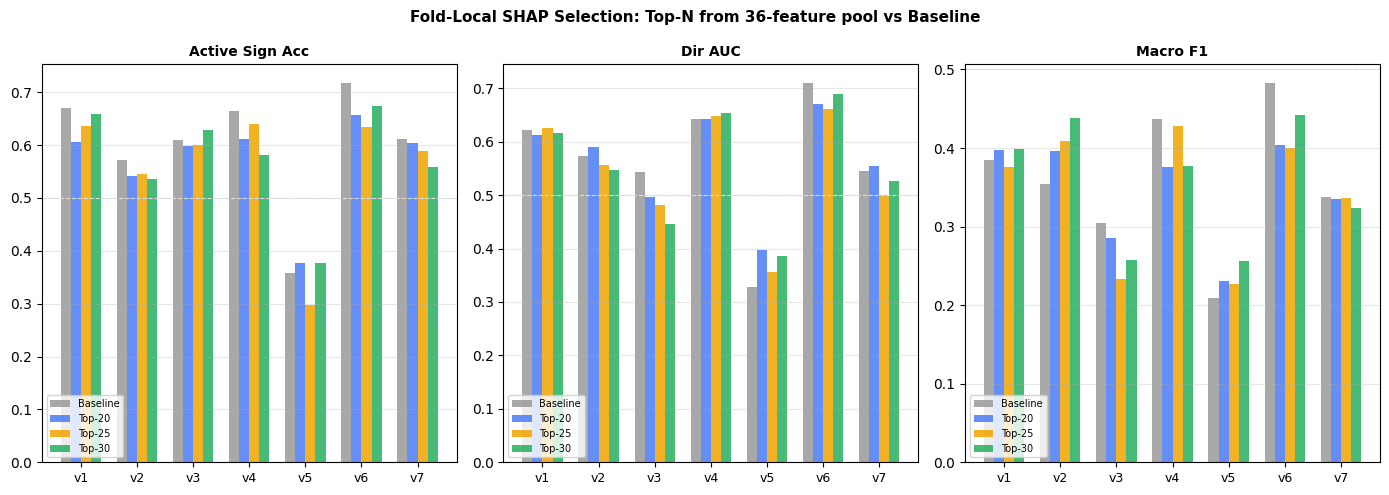

In [7]:
# ── Per-fold breakdown chart ──────────────────────────────────────────────────
folds   = list(E10_FOLDS[i][0] for i in range(len(E10_FOLDS)))
x       = np.arange(len(folds))
configs = [('Baseline', baseline_df, '#999')] +           [(f'Top-{n}', result_dfs[n], c)
           for n, c in zip(TOP_N_VALUES, ['#4a7cf6','#f0a500','#27ae60'])]
w       = 0.18
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (metric, ylabel) in zip(axes, [
    ('active_asa', 'Active Sign Acc'),
    ('dir_auc',    'Dir AUC'),
    ('macro_f1',   'Macro F1'),
]):
    for ci, (label, rdf, color) in enumerate(configs):
        offset = (ci - len(configs)/2 + 0.5) * w
        ax.bar(x + offset, rdf[metric].values, w,
               label=label, color=color, alpha=0.85)
    ax.axhline(0.5, color='#ddd', linestyle='--', linewidth=0.8)
    ax.set_xticks(x); ax.set_xticklabels(folds, fontsize=9)
    ax.set_title(ylabel, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='lower left'); ax.grid(axis='y', alpha=0.3)

plt.suptitle('Fold-Local SHAP Selection: Top-N from 36-feature pool vs Baseline',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Which TA Features Were Selected?

In [8]:
# ── How often does each TA feature appear across all 7 folds? ────────────────
print('=== TA Feature Selection Frequency (out of 7 folds) ===\n')
print(f'  {"Feature":<25} ', end='')
for n in TOP_N_VALUES:
    print(f'top-{n}  ', end='')
print()
print('-' * 55)

for feat in TA_ADDITIONS:
    print(f'  {feat:<25} ', end='')
    for n in TOP_N_VALUES:
        count = sum(1 for fold_id in selected_features[n]
                    if feat in selected_features[n][fold_id])
        print(f'{count:>3}/7   ', end='')
    print()

# ── Global SHAP importance ranking across all folds ───────────────────────────
shap_df     = pd.DataFrame(shap_records)
global_mean = shap_df.mean().sort_values(ascending=False)

print(f'\n=== Global SHAP Rank (mean |SHAP| across 7 folds, 36-feature pool) ===')
for rank, (feat, val) in enumerate(global_mean.items(), 1):
    tag = '  ← TA addition' if feat in TA_ADDITIONS else ''
    print(f'  {rank:2d}. {feat:<30} {val:.4f}{tag}')

=== TA Feature Selection Frequency (out of 7 folds) ===

  Feature                   top-20  top-25  top-30  
-------------------------------------------------------
  td_rsi_14                   3/7     3/7     7/7   
  td_bb_position              3/7     5/7     6/7   
  td_rsv_14d                  4/7     7/7     7/7   
  td_beta_20d                 6/7     6/7     7/7   
  td_resi_20d                 6/7     7/7     7/7   
  td_wvma_5d                  7/7     7/7     7/7   

=== Global SHAP Rank (mean |SHAP| across 7 folds, 36-feature pool) ===
   1. evt_guidance_shift             0.1566
   2. td_corr_pv_20d                 0.1127
   3. td_vs_xfn_5d                   0.1041
   4. evt_cfo_tone                   0.0958
   5. td_wvma_5d                     0.0712  ← TA addition
   6. td_beta_20d                    0.0707  ← TA addition
   7. news_sent_mean_30d             0.0694
   8. td_vs_tsx_5d                   0.0674
   9. yield_10y_level                0.0669
  10. fx_usdcad_le

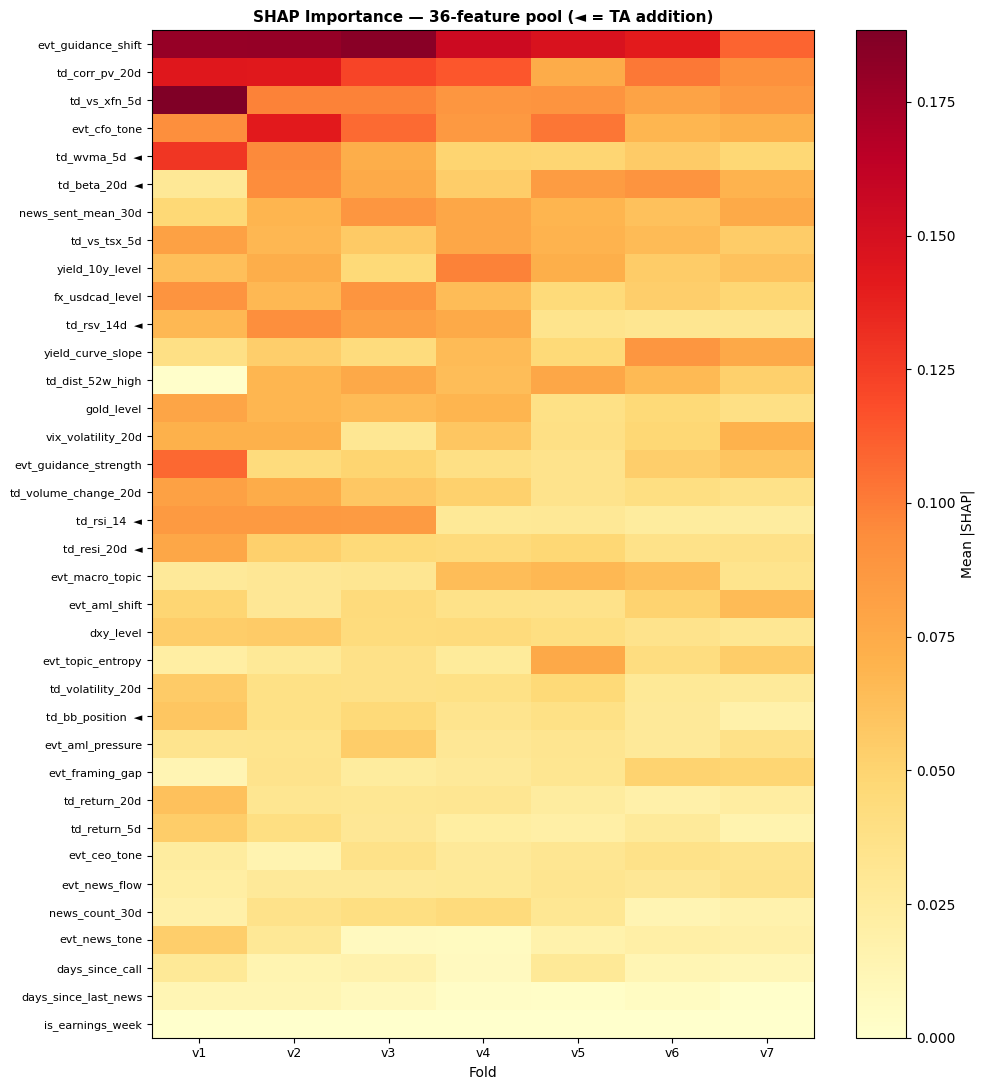

In [9]:
# ── SHAP importance heatmap: all 36 features across 7 folds ──────────────────
fig, ax = plt.subplots(figsize=(10, 11))
# Sort features by global mean importance
sorted_feats = global_mean.index.tolist()
heat = shap_df[sorted_feats].T

im = ax.imshow(heat.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, fontsize=9)
ax.set_yticks(range(len(sorted_feats)))
yticklabels = [f'{f}  ◄' if f in TA_ADDITIONS else f for f in sorted_feats]
ax.set_yticklabels(yticklabels, fontsize=8)
ax.set_xlabel('Fold', fontsize=10)
ax.set_title('SHAP Importance — 36-feature pool (◄ = TA addition)',
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean |SHAP|')
plt.tight_layout(); plt.show()

## 7. Save Artifact

If any top-N selection beats the baseline on **both** ASA and Dir AUC, set `SAVE = True`
and set `SAVE_N` to the N value you want to save. The notebook will train a final model
on all available data using the globally most-common top-N feature set and save it to
`final_model_experiment/artifacts/`.

The `final_model/artifacts/` folder is **never touched**.

In [10]:
SAVE   = False   # ← set to True after reviewing results
SAVE_N = 25      # ← which top-N to save (20, 25, or 30)

if not SAVE:
    print('SAVE=False — artifact not saved. Set SAVE=True to save.')
else:
    # For the saved model, use the features that appeared most often
    # in the fold-local selections (majority vote across 7 folds)
    feature_votes = {}
    for fold_id in selected_features[SAVE_N]:
        for feat in selected_features[SAVE_N][fold_id]:
            feature_votes[feat] = feature_votes.get(feat, 0) + 1
    # Sort by vote count, then by global SHAP importance for ties
    sorted_by_vote = sorted(feature_votes.items(),
                             key=lambda x: (x[1], global_mean.get(x[0], 0)),
                             reverse=True)
    FINAL_FEATURES = [f for f, _ in sorted_by_vote[:SAVE_N]]

    print(f'Saving top-{SAVE_N} majority-voted feature set:')
    for i, f in enumerate(FINAL_FEATURES, 1):
        tag = '  ← TA' if f in TA_ADDITIONS else ''
        votes = feature_votes.get(f, 0)
        print(f'  {i:2d}. {f:<30} ({votes}/7 folds){tag}')

    # Train on all data
    full_df    = df[df[TARGET].notna()].copy()
    train_end  = full_df['date'].max()
    x_full     = full_df[FINAL_FEATURES].fillna(full_df[FINAL_FEATURES].median())
    y_full     = label_3class(full_df[TARGET].values, threshold=THRESHOLD)
    y_enc      = np.array([label_map[v] for v in y_full], dtype=int)
    final_clf  = lgb.LGBMClassifier(objective='multiclass', num_class=3,
                                     random_state=42, verbose=-1, n_jobs=1,
                                     **LOCKED_PARAMS)
    final_clf.fit(x_full, y_enc)

    TODAY       = date.today().isoformat()
    ARTIFACT_ID = f'ta_shap{SAVE_N}-{TODAY}'
    PKL_PATH    = EXP_ART_DIR / f'{ARTIFACT_ID}.pkl'
    JSON_PATH   = EXP_ART_DIR / f'{ARTIFACT_ID}.json'

    import pickle as _pkl
    with open(PKL_PATH, 'wb') as f:
        _pkl.dump({
            'model': final_clf, 'features': FINAL_FEATURES,
            'target': TARGET, 'threshold': THRESHOLD,
            'label_map': label_map, 'inverse_label_map': inv_map,
            'best_params': LOCKED_PARAMS,
            'ta_features_in_set': [f for f in FINAL_FEATURES if f in TA_ADDITIONS],
            'selection_method': f'fold-local-SHAP-top{SAVE_N}-majority-vote',
            'train_rows': len(full_df), 'train_end': str(train_end.date()),
            'artifact_id': ARTIFACT_ID,
        }, f)

    m_saved = result_dfs[SAVE_N].mean()
    with open(JSON_PATH, 'w') as f:
        json.dump({
            'artifact_id': ARTIFACT_ID, 'created': TODAY,
            'source': 'ta_shap_selection.ipynb',
            'selection_method': f'fold-local-SHAP-top{SAVE_N}-majority-vote',
            'n_features': SAVE_N,
            'ta_features_in_set': [f for f in FINAL_FEATURES if f in TA_ADDITIONS],
            'best_params': LOCKED_PARAMS,
            'eval_asa': round(float(m_saved.active_asa), 3),
            'eval_dir_auc': round(float(m_saved.dir_auc), 3),
            'eval_macro_f1': round(float(m_saved.macro_f1), 3),
            'baseline_asa': round(float(bl.active_asa), 3),
            'baseline_dir_auc': round(float(bl.dir_auc), 3),
            'features': FINAL_FEATURES,
            'target': TARGET, 'threshold': THRESHOLD,
            'train_rows': int(len(full_df)), 'train_end': str(train_end.date()),
            'artifact_path': str(PKL_PATH),
        }, f, indent=2)

    print(f'\nSaved : {PKL_PATH.name}')
    print(f'Run ta_features_performance.ipynb to get SHAP analysis.')

SAVE=False — artifact not saved. Set SAVE=True to save.
